# Tutorial 5: SurEau-Medlyn Basic run 


## Load modules

In [ ]:
from plotnine import *
from plotnine import *
import numpy as np, pandas as pd
from itables import to_html_datatable
from IPython.display import HTML, display

In [ ]:
from plant_hydraulics.run_sureau import run_sureau
from plant_hydraulics.sureau_climate import *  
from plant_hydraulics.utils import potential_PAR
from plant_hydraulics.parameter_classes import (
    SurEauVegetationParams,
    SurEauSoilParams,
    SurEauModelOptions,
)

from plant_hydraulics.utils import (
    load_example_data,
)

# Object initialization

In [ ]:

# Model options
opts = SurEauModelOptions(
    
    # Richmond
    latitude=-33.5996,
    
    # Meters above sea level
    elevation = 24,
    
    # net radiation model: "Linacre" (only option currently)
    Rn_formulation="Linacre",
    
    # PET model: "PT" (Priestley-Taylor) or "PM" (Penman-Monteith)
    ETP_formulation="PM",
    
    # True → forces a fixed doy=116 (sunny day template)
    constant_climate = False,
    # which hours to output (0–23 → full day)
    time_steps=np.arange(24),
    
    # Print progress to console
    print_progress=True,
    
    year_start=2016,
    year_end=2016
)

In [ ]:
# Vegetation parameters
veg_params = SurEauVegetationParams()

In [ ]:
# Leaf area index (m²/m²). Higher = more transpiration.
veg_params.LAI_max = 4.5     
  
veg_params.foliage = "Evergreen"  

veg_params.transpiration_model = "Medlyn"

# Params from Drake 
veg_params.vcmax25 = 34
veg_params.vcmaxha = 51780
veg_params.vcmaxhd = 2e5
veg_params.vcmaxse = 640

veg_params.jmax25 = 60
veg_params.jmaxha = 21640
veg_params.jmaxhd = 2e5
veg_params.jmaxse = 633

veg_params.g1_medlyn = 2.9
veg_params.g0_medlyn = 0.003


# ψ at 50% loss of leaf conductance (MPa) 
veg_params.P50_VC_leaf = -3.4

# ψ at 50% loss of stem conductance (MPa)   
veg_params.P50_VC_stem = -3.4

# Steepness of vulnerability sigmoid (%/MPa)   
veg_params.slope_VC_leaf = 60   

# ψ at 12% stomatal closure (MPa)
veg_params.P12_gs = -2.07

# ψ at 88% stomatal closure (MPa)       
veg_params.P88_gs = -2.62       

# Whole-plant conductance (mmol/m²/s/MPa)
veg_params.k_plant_init = 0.62  

# At 20°C (mmol/m²/s)
veg_params.gmin20 = 4.0

# Temperature where cuticle melts (°C)         
veg_params.TPhase_gmin = 37.5

# Q10 above TPhase    
veg_params.Q10_2_gmin = 4.8     


In [ ]:
soil_params = SurEauSoilParams()

## Climate

SurEau takes daily climatic data and then creates a hourly dataset 

In [ ]:

climate_df = load_example_data("sureau_medlyn_daily_climate.csv", sep=",")
#climate_df["DATE"] = pd.to_datetime(climate_df["DATE"], format="%d/%m/%Y").dt.strftime("%Y-%m-%d")
html_str = to_html_datatable(climate_df)
display(HTML(html_str))

Loading ITables v2.8.1 from the internet... (need help?)


### Explore climatic data

In [ ]:
hourly_data_from_daily = []
for each_day in range(len(climate_df)):
    
    # Get date 
    date_str = str(climate_df.iloc[each_day]["DATE"])              
   
    # Calculate climate for that day
    clim = new_climate_day(climate_df, date_str)
    
    # Compute PET for that day
    clim = compute_Rn_and_ETP(clim, veg_params, opts)
    
    # Create hourly climate from daily conditions     
    ch   = new_climate_hourly(clim, opts, veg_params)    
    
    #Show data in ch
    #print("ch.__dict__ keys:", list(vars(ch).keys()))
    
    # Put everything into frame that works for Sureau
    hourly_data_from_daily.append(pd.DataFrame({
        "Doy":    int(climate_df.iloc[each_day]["DOY"]),
        "hour":   np.asarray(ch.time, float),
        "RG":     np.asarray(ch.RG, float), 
        "RH":     np.asarray(ch.RH_air_mean, float),           
        "PAR_d":  np.asarray(ch.PAR, float),
        "Tair_d": np.asarray(ch.T_air_mean, float),
        "VPD_d":  np.asarray(ch.VPD, float),
    }))
hourly_data_from_daily = pd.concat(hourly_data_from_daily, ignore_index=True)

ETP_formulation is PM
Remember to adjust the lat/lon
ETP_formulation is PM
Remember to adjust the lat/lon
ETP_formulation is PM
Remember to adjust the lat/lon
ETP_formulation is PM
Remember to adjust the lat/lon


## Run the model

In [ ]:
results = run_sureau(
    climate_df=climate_df,
    veg_params=veg_params,
    soil_params=soil_params,
    opts=opts,
    
    # Set True to keep deepest layer at field capacity
    deep_water=True,  
)


Year 2016 Day 305
 ETP_formulation is PM
Remember to adjust the lat/lon
Year 2016 Day 306
 ETP_formulation is PM
Remember to adjust the lat/lon
Year 2016 Day 307
 ETP_formulation is PM
Remember to adjust the lat/lon
Year 2016 Day 308
 ETP_formulation is PM
Remember to adjust the lat/lon
Year 2016 complete. 


In [ ]:
html_str = to_html_datatable(results)
display(HTML(html_str))

Loading ITables v2.8.1 from the internet... (need help?)


##  Plot results 

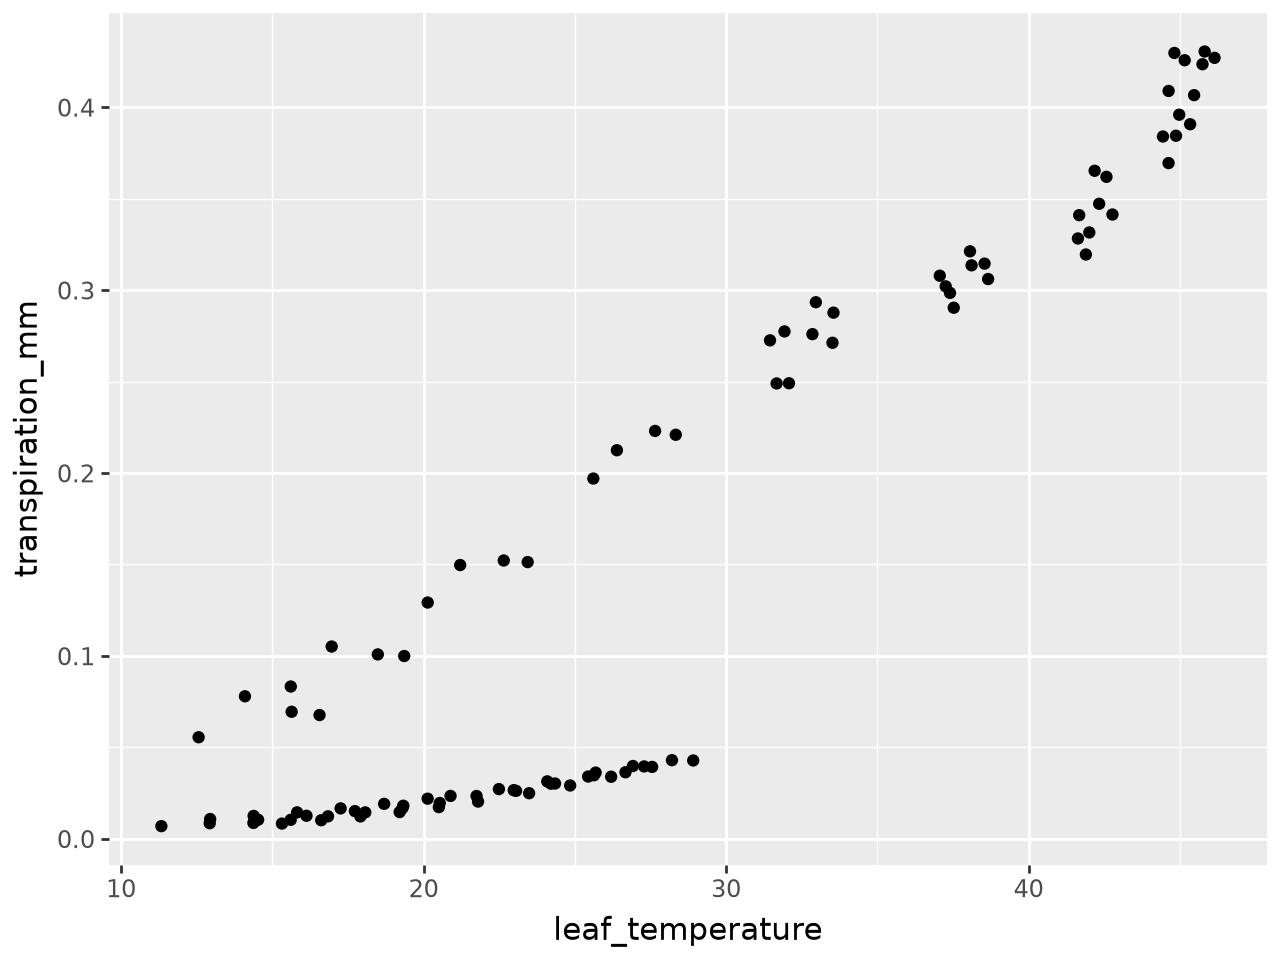

In [ ]:
ggplot(results, aes(x = "leaf_temperature", y = "transpiration_mm" )) + geom_point()